In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\charl\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Load data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Define the full path to your file using a "raw string" (r"...")
file_path = r"C:\Users\charl\OneDrive - UNSW\2025\2025 T3\DATA3001\Stage 2 - Modelling\Code\fixed_final_data_product.csv"

# Load the CSV into a DataFrame
df = pd.read_csv(file_path)

df.head()

,lap_id,invalid_lap,BPS_SPEED,BPS_THROTTLE,BPS_STEER,BPS_BRAKE,BPS_CURRENTLAPTIMEINMS,BPS_LAPDISTANCE,BPS_WORLDPOSITIONX,BPS_WORLDPOSITIONY,...,dist_530_YAW,dist_530_PITCH,dist_530_ROLL,dist_530_left_dist,dist_530_right_dist,dist_530_dist_apex_1,dist_530_dist_apex_2,dist_530_angle_to_apex1,dist_530_angle_to_apex2,dist_530_proj_from_ref
0,10021698834789871149_1,1,316.0,1.000000,0.074568,0.0,2615.0,223.0,274.071987,313.458779,...,-2.715189,0.000475,-0.016953,1.741342,10.851370,132.666175,33.599712,-177.333510,-157.363838,3.100772
1,10021698834789871149_10,1,324.0,0.970802,0.000464,0.0,3097.0,273.0,310.096901,278.846172,...,-2.677639,-0.002429,-0.010994,5.229576,7.362893,134.315712,34.235318,-178.276773,-162.785343,0.365266
2,10021698834789871149_11,1,322.0,1.000000,-0.002375,0.0,2976.0,258.0,298.743940,288.688005,...,-2.672484,-0.003209,-0.015086,4.491344,8.101110,133.962370,34.073817,-177.906287,-161.483133,0.368740
3,10021698834789871149_12,0,322.0,0.025177,0.006011,0.0,3049.0,269.0,307.165908,281.569461,...,-2.683784,-0.003549,-0.013458,4.000375,8.592165,133.726732,33.972230,-177.665140,-160.617290,0.856654
4,10021698834789871149_13,1,324.0,1.000000,0.021114,0.0,3046.0,268.0,306.397540,282.215448,...,-2.576070,0.002121,-0.016932,5.969796,6.622633,134.674490,34.413890,-179.086529,-164.518584,1.101108


## Data Processing

### Cleaning Data

In [4]:
from sklearn.impute import SimpleImputer

# the only non-numeric column is 'lap_id', so we can focus on numeric columns only

# Select numeric columns
num_cols = df.select_dtypes(include=["number"]).columns

# Find columns that have missing values
missing_cols = [col for col in num_cols if df[col].isna().any()]

# Compute skewness for those columns
skewness_values = df[missing_cols].skew().to_dict()

# Split columns based on skewness
# use median for skewed data (|skewness| >= 0.5), mean for symmetric
median_cols = [col for col, skew in skewness_values.items() if abs(skew) >= 0.5]
mean_cols   = [col for col, skew in skewness_values.items() if abs(skew) < 0.5]

# Apply imputers
median_imputer = SimpleImputer(strategy="median")
mean_imputer   = SimpleImputer(strategy="mean")

if median_cols:
    df[median_cols] = median_imputer.fit_transform(df[median_cols])

if mean_cols:
    df[mean_cols] = mean_imputer.fit_transform(df[mean_cols])


### Feature Selection

In [5]:
correlation_matrix = df.corr()
print(correlation_matrix["Target_CURRENTLAPTIMEINMS"].sort_values(ascending=False))

Target_CURRENTLAPTIMEINMS      1.000000
STM_CURRENTLAPTIMEINMS         0.860692
STE_CURRENTLAPTIMEINMS         0.854401
STS_CURRENTLAPTIMEINMS         0.819789
dist_530_CURRENTLAPTIMEINMS    0.815895
                                 ...   
dist_530_SPEED                -0.512912
STE_SPEED                     -0.514843
dist_360_LAPDISTANCE                NaN
dist_430_LAPDISTANCE                NaN
dist_530_LAPDISTANCE                NaN
Name: Target_CURRENTLAPTIMEINMS, Length: 255, dtype: float64


In [6]:
# Focus on relevant driving features and target variable
"""
turn_features = [
    'BPS_SPEED', 'BPS_THROTTLE', 'BPS_STEER', 'BPS_BRAKE',
    'BPE_SPEED', 'BPE_THROTTLE', 'BPE_STEER', 'BPE_BRAKE',
    'STE_SPEED', 'STE_THROTTLE', 'STE_STEER', 'STE_BRAKE',
    'STM_SPEED', 'STM_THROTTLE', 'STM_STEER', 'STM_BRAKE',
    'APX1_SPEED', 'APX1_THROTTLE', 'APX1_STEER', 'APX1_BRAKE',
    'APX2_SPEED', 'APX2_THROTTLE', 'APX2_STEER', 'APX2_BRAKE'
]
"""

driver_input = ['BPS_SPEED', 'BPS_THROTTLE', 'BPS_STEER', 'BPS_BRAKE', 'BPS_CURRENTLAPTIMEINMS', 
             'BPS_LAPDISTANCE', 'BPS_WORLDPOSITIONX', 'BPS_WORLDPOSITIONY', 'BPE_SPEED', 'BPE_THROTTLE', 
             'BPE_STEER', 'BPE_BRAKE', 'BPE_CURRENTLAPTIMEINMS', 'BPE_LAPDISTANCE', 'BPE_WORLDPOSITIONX', 'BPE_WORLDPOSITIONY',
            'THS_SPEED', 'THS_THROTTLE', 'THS_STEER', 'THS_BRAKE', 'THS_CURRENTLAPTIMEINMS', 'THS_LAPDISTANCE', 'THS_WORLDPOSITIONX', 
             'THS_WORLDPOSITIONY', 'THE_SPEED', 'THE_THROTTLE', 'THE_STEER', 'THE_BRAKE', 'THE_CURRENTLAPTIMEINMS', 
             'THE_LAPDISTANCE', 'THE_WORLDPOSITIONX', 'THE_WORLDPOSITIONY', 'STS_SPEED', 'STS_THROTTLE', 'STS_STEER', 'STS_BRAKE', 
             'STS_CURRENTLAPTIMEINMS', 'STS_LAPDISTANCE', 'STS_WORLDPOSITIONX', 'STS_WORLDPOSITIONY', 'STM_SPEED', 'STM_THROTTLE', 
             'STM_STEER', 'STM_BRAKE', 'STM_CURRENTLAPTIMEINMS', 'STM_LAPDISTANCE', 'STM_WORLDPOSITIONX', 'STM_WORLDPOSITIONY', 
            'STE_SPEED', 'STE_THROTTLE', 'STE_STEER', 'STE_BRAKE', 'STE_CURRENTLAPTIMEINMS', 'STE_LAPDISTANCE', 'STE_WORLDPOSITIONX', 
             'STE_WORLDPOSITIONY']

In [7]:
df_model = df[driver_input + ['Target_CURRENTLAPTIMEINMS']].copy()

## Train / Test Split

In [8]:
from sklearn.model_selection import train_test_split

# Split data
X = df_model.drop(columns=['Target_CURRENTLAPTIMEINMS'])  # Features
y = df_model['Target_CURRENTLAPTIMEINMS']                 # Target variable

# X = df.drop(columns=['Target_CURRENTLAPTIMEINMS'])  # Features
# y = df['Target_CURRENTLAPTIMEINMS']                 # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (825, 56)
Test set size: (207, 56)


In [9]:
# Standardize features - ensure all variables on the same scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression (Baseline Model)

### Simple Linear Regression

In [10]:
from sklearn.linear_model import LinearRegression

# Train linear regression model
model = LinearRegression()

# Fit model to training data
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Predict values on testing data
y_pred = model.predict(X_test_scaled)

In [13]:
# Evaluate model performance
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error

def evaluate_model(y_true, y_pred, X_test):
    n = X_test.shape[0]
    p = X_test.shape[1]
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    return mse, rmse, mae, r2, r2_adj

In [14]:
# Present evaluation results
print("Model Evaluation on Test Set:")
mse, rmse, mae, r2, r2_adj = evaluate_model(y_test, y_pred, X_test)
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {r2_adj:.4f}")

Model Evaluation on Test Set:
MSE: 2915701.85
RMSE: 1707.54
MAE: 982.52
R²: 0.5083
Adjusted R²: 0.3247


In [15]:
# Identify the top 20 predictive features based on absolute coefficient values
results = []

X = df_model.drop(columns=["Target_CURRENTLAPTIMEINMS"])
y = df_model["Target_CURRENTLAPTIMEINMS"]

for col in X.columns:
    # Drop missing values if any
    valid = df_model[[col, "Target_CURRENTLAPTIMEINMS"]].dropna()
    x = valid[[col]]
    y_single = valid["Target_CURRENTLAPTIMEINMS"]

    model = LinearRegression().fit(x, y_single)
    y_pred = model.predict(x)

    r2 = r2_score(y_single, y_pred)
    results.append((col, r2))

# Sort by R² descending
simple_reg_rank = sorted(results, key=lambda x: x[1], reverse=True)
top20_simple = simple_reg_rank[:20]

for name, r2 in top20_simple:
    print(f"{name:<35} R² = {r2:.3f}")

STM_CURRENTLAPTIMEINMS              R² = 0.741
STE_CURRENTLAPTIMEINMS              R² = 0.730
STS_CURRENTLAPTIMEINMS              R² = 0.672
BPE_CURRENTLAPTIMEINMS              R² = 0.424
STE_SPEED                           R² = 0.265
STM_SPEED                           R² = 0.256
BPS_SPEED                           R² = 0.231
BPS_CURRENTLAPTIMEINMS              R² = 0.174
STS_SPEED                           R² = 0.160
THS_CURRENTLAPTIMEINMS              R² = 0.143
STS_LAPDISTANCE                     R² = 0.138
STS_WORLDPOSITIONY                  R² = 0.127
STS_BRAKE                           R² = 0.116
BPE_BRAKE                           R² = 0.110
STS_THROTTLE                        R² = 0.107
THS_SPEED                           R² = 0.105
THE_SPEED                           R² = 0.098
STE_THROTTLE                        R² = 0.097
BPS_WORLDPOSITIONY                  R² = 0.073
BPE_THROTTLE                        R² = 0.069


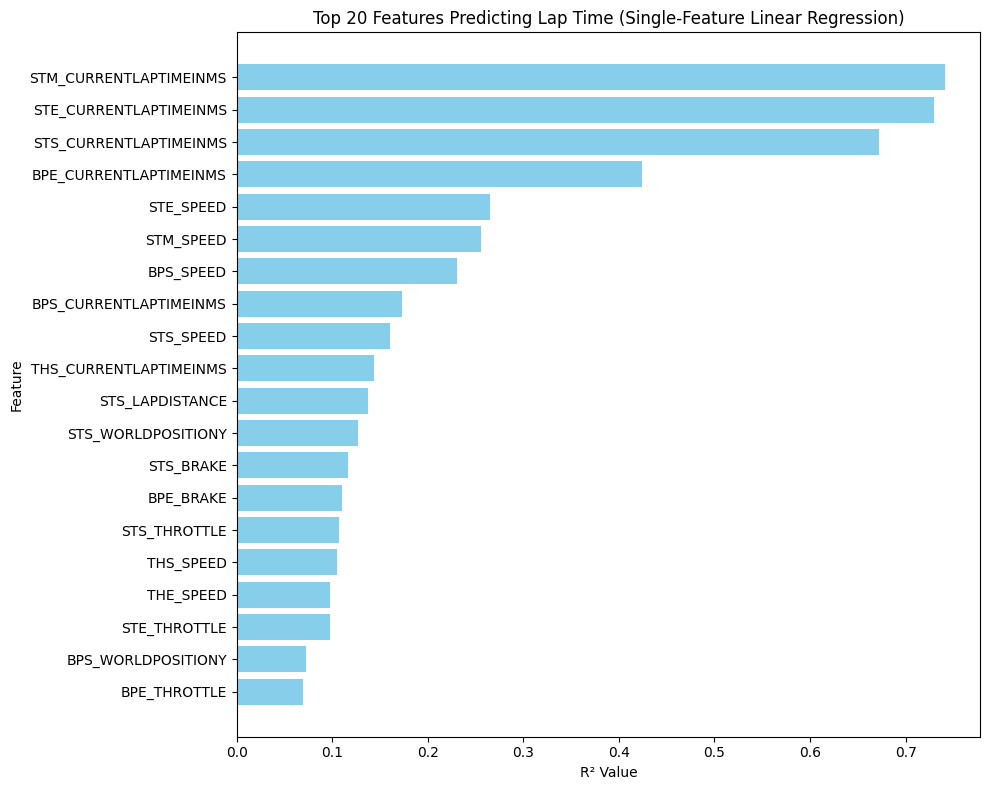

In [16]:
# Convert top20_simple into a DataFrame for plotting
top20_df = pd.DataFrame(top20_simple, columns=["Feature", "R2"])

# Sort ascending for horizontal bar chart (largest R² at top)
top20_df = top20_df.sort_values(by="R2", ascending=True)

plt.figure(figsize=(10,8))
plt.barh(top20_df["Feature"], top20_df["R2"], color="skyblue")
plt.xlabel("R² Value")
plt.ylabel("Feature")
plt.title("Top 20 Features Predicting Lap Time (Single-Feature Linear Regression)")
plt.tight_layout()
plt.show()


## Elastic Net Regression

### Preliminary EN Model (alpha=0.5)

In [17]:
from sklearn.linear_model import ElasticNet

elastic_net_model = ElasticNet(alpha=0.5, l1_ratio=0.7, random_state=42)
elastic_net_model.fit(X_train_scaled, y_train) # edit: scaled

,alpha,0.5
,l1_ratio,0.7
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [18]:
# Predict with Elastic Net
y_enet_pred = elastic_net_model.predict(X_test_scaled)

# Evaluate Elastic Net model (preliminary)
r2_enet = r2_score(y_test, y_enet_pred)
mse_enet = mean_squared_error(y_test, y_enet_pred)
print(f"Elastic Net R^2 Score: {r2_enet}")
print(f"Elastic Net MSE: {mse_enet}")

Elastic Net R^2 Score: 0.663223174208311
Elastic Net MSE: 1996991.3500649547


### Final tuned EN model (optimal parameters)

Hyperparameter Tuning (to find optimal alpha & l1_ratio)

In [21]:
from sklearn.linear_model import ElasticNetCV

# Set Up ElasticNetCV
ElasticNetCV = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
                            #alphas=np.logspace(-4, -1, 100),
                            alphas=np.logspace(-4, 3, 200), # widened range
                            cv=5, # number of cross validation folds
                            random_state=42)

# Fit ElasticNetCV to training data
ElasticNetCV.fit(X_train_scaled, y_train)

C:\Users\charl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.616e+06, tolerance: 4.415e+06
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\charl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.961e+06, tolerance: 4.415e+06
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\charl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Local

Optimal alpha: 9.884959046625585
Optimal l1_ratio: 0.99


In [ ]:
# Optimal hyperparameters
ElasticNetCV.alpha_  # optimal alpha
ElasticNetCV.l1_ratio_  # optimal l1_ratio
print(f"Optimal alpha: {ElasticNetCV.alpha_}")
print(f"Optimal l1_ratio: {ElasticNetCV.l1_ratio_}")

Optimal alpha: 9.884959046625585
Optimal l1_ratio: 0.99


In [22]:
# Checking chosen range at [73] is optimal
print("Chosen alpha:", ElasticNetCV.alpha_)
print("Alpha range:", ElasticNetCV.alphas_[0], "→", ElasticNetCV.alphas_[-1])

Chosen alpha: 9.884959046625585
Alpha range: 1000.0 → 0.0001


In [23]:
# Use optimal hyperparameters to train final model
final_enet_model = ElasticNet(
    alpha=ElasticNetCV.alpha_,
    l1_ratio=ElasticNetCV.l1_ratio_,
    random_state=42
)

# Fit final Elastic Net model
final_enet_model.fit(X_train_scaled, y_train)

# Predict with final Elastic Net model
y_final_enet_pred = final_enet_model.predict(X_test_scaled)

In [26]:
# Evaluate using the unified evaluation function
mse_final, rmse_final, mae_final, r2_final, r2_adj_final = evaluate_model(
    y_test, y_final_enet_pred, X_test_scaled
)

print("Final Tuned Elastic Net Evaluation:")
print(f"MSE: {mse_final:.4f}")
print(f"RMSE: {rmse_final:.4f}")
print(f"MAE: {mae_final:.4f}")
print(f"R²: {r2_final:.4f}")
print(f"Adjusted R²: {r2_adj_final:.4f}")

Final Tuned Elastic Net Evaluation:
MSE: 1987021.4904
RMSE: 1409.6175
MAE: 879.4120
R²: 0.6649
Adjusted R²: 0.5398
